In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [2]:
import tensorflow as tf
tf.config.run_functions_eagerly(True) # This ensures eager execution within tf.function
from tensorflow.keras.datasets import mnist
from tensorflow.keras import layers
from tensorflow.keras.optimizers import Adam

2025-06-23 19:01:14.499502: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1750705274.685300      77 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1750705274.736034      77 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
# Load dataset
(X_train, y_train), (X_test, y_test) = mnist.load_data()
num_samples = 40000
X_train = X_train[ : num_samples ]
y_train = y_train[ : num_samples ]
print ( X_train.shape )

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(40000, 28, 28)


In [4]:
print('X_train.shape', X_train.shape)

# Reshape and normalize
X_train = X_train.reshape( X_train.shape[0], 28, 28, 1 ).astype('float32')
X_train = ( X_train / 255 - 0.5 ) * 2
print('X_train reshape:', X_train.shape)

# Batch and shuffle the data
batch_size = 256
train_dataset = tf.data.Dataset.from_tensor_slices( X_train ).shuffle(num_samples).batch( batch_size )

X_train.shape (40000, 28, 28)
X_train reshape: (40000, 28, 28, 1)


I0000 00:00:1750705288.163095      77 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15513 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


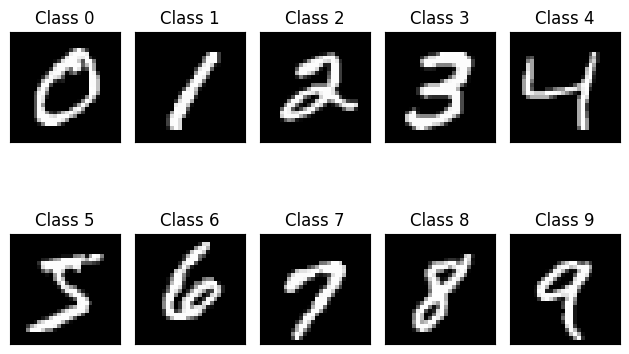

In [5]:
fig = plt.figure()
for i in range(10):
    plt.subplot(2, 5, i+1)
    x_y = X_train[y_train == i]
    plt.imshow(x_y[0], cmap='gray', interpolation='none')
    plt.title("Class %d" % (i))
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()

In [6]:
latent_dim = 100
def generator_model():
    model = tf.keras.Sequential()
    model.add( tf.keras.Input( shape=(latent_dim,) ) )
    model.add(layers.Dense( 7*7*256, use_bias=False ) )
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Reshape((7, 7, 256)))
    assert model.output_shape == (None, 7, 7, 256)  # Note: None is the batch size

    model.add(layers.Conv2DTranspose(128, (5, 5), strides=(1, 1), padding='same', use_bias=False))
    assert model.output_shape == (None, 7, 7, 128)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(64, (5, 5), strides=(2, 2), padding='same', use_bias=False))
    assert model.output_shape == (None, 14, 14, 64)
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU())

    model.add(layers.Conv2DTranspose(1, (5, 5), strides=(2, 2), padding='same', use_bias=False, activation='tanh'))
    assert model.output_shape == (None, 28, 28, 1)

    return model
generator = generator_model()

In [7]:
def discriminator_model():
    model = tf.keras.Sequential()
    model.add( tf.keras.Input( shape=[28, 28, 1] ) )
    model.add( layers.Conv2D(64, (5, 5), strides=(2, 2), padding='same') )
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Conv2D(128, (5, 5), strides=(2, 2), padding='same'))
    model.add(layers.LeakyReLU())
    model.add(layers.Dropout(0.3))

    model.add(layers.Flatten())
    model.add(layers.Dense(1))

    return model
discriminator = discriminator_model()

I0000 00:00:1750705290.914476      77 cuda_dnn.cc:529] Loaded cuDNN version 90300


Epoch: 0, disc. loss: 0.6797048449516296, gen. loss: 0.6871891021728516. Time for epoch 1 is 31.63149380683899 sec
Epoch: 1, disc. loss: 0.6366842985153198, gen. loss: 0.6744229793548584. Time for epoch 2 is 28.015098333358765 sec
Epoch: 2, disc. loss: 0.6849801540374756, gen. loss: 0.6819462776184082. Time for epoch 3 is 28.041154623031616 sec
Epoch: 3, disc. loss: 0.6434956789016724, gen. loss: 0.6683037877082825. Time for epoch 4 is 28.190945625305176 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


/usr/local/lib/python3.11/dist-packages/tensorflow/python/data/ops/structured_function.py:258: UserWarning: Even though the `tf.config.experimental_run_functions_eagerly` option is set, this option does not apply to tf.data functions. To force eager execution of tf.data functions, please use `tf.data.experimental.enable_debug_mode()`.
  warnings.warn(


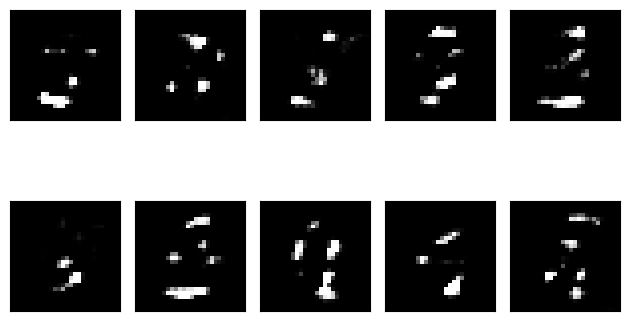

Epoch: 4, disc. loss: 0.6698100566864014, gen. loss: 0.6874695420265198. Time for epoch 5 is 28.378562211990356 sec
Epoch: 5, disc. loss: 0.6594189405441284, gen. loss: 0.6790182590484619. Time for epoch 6 is 27.94334053993225 sec
Epoch: 6, disc. loss: 0.664531946182251, gen. loss: 0.7777908444404602. Time for epoch 7 is 28.140836477279663 sec
Epoch: 7, disc. loss: 0.6338945031166077, gen. loss: 0.8519946336746216. Time for epoch 8 is 27.94337034225464 sec
Epoch: 8, disc. loss: 0.6350417733192444, gen. loss: 0.7890561819076538. Time for epoch 9 is 28.058143138885498 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


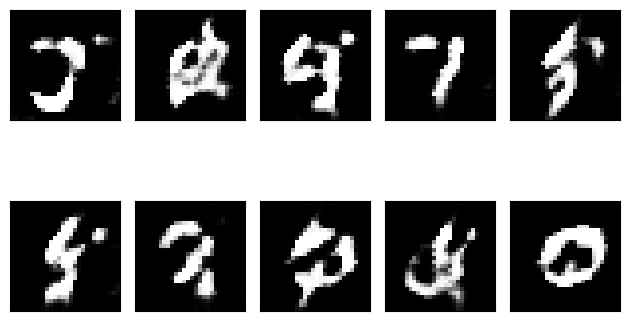

Epoch: 9, disc. loss: 0.6360802054405212, gen. loss: 0.7821388840675354. Time for epoch 10 is 28.45254898071289 sec
Epoch: 10, disc. loss: 0.6315101385116577, gen. loss: 0.8360806703567505. Time for epoch 11 is 28.120720386505127 sec
Epoch: 11, disc. loss: 0.6154730319976807, gen. loss: 0.7304123044013977. Time for epoch 12 is 28.152733325958252 sec
Epoch: 12, disc. loss: 0.678410530090332, gen. loss: 0.7620567679405212. Time for epoch 13 is 28.095700979232788 sec
Epoch: 13, disc. loss: 0.7269890308380127, gen. loss: 0.7806970477104187. Time for epoch 14 is 28.116742372512817 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


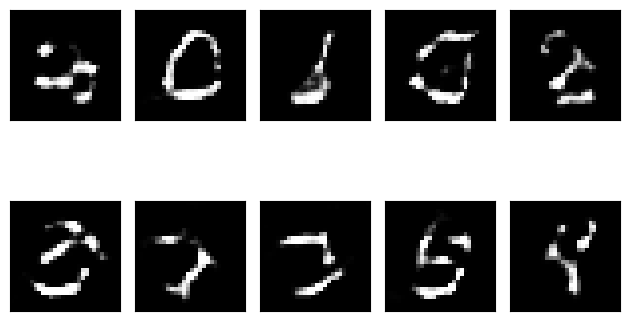

Epoch: 14, disc. loss: 0.7061108350753784, gen. loss: 0.7875953912734985. Time for epoch 15 is 28.448034286499023 sec
Epoch: 15, disc. loss: 0.6675117611885071, gen. loss: 0.6428830623626709. Time for epoch 16 is 28.0636146068573 sec
Epoch: 16, disc. loss: 0.6540151834487915, gen. loss: 0.7025273442268372. Time for epoch 17 is 27.94355058670044 sec
Epoch: 17, disc. loss: 0.6948344707489014, gen. loss: 0.6999776363372803. Time for epoch 18 is 27.84014391899109 sec
Epoch: 18, disc. loss: 0.6924936771392822, gen. loss: 0.7476199269294739. Time for epoch 19 is 27.849411010742188 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


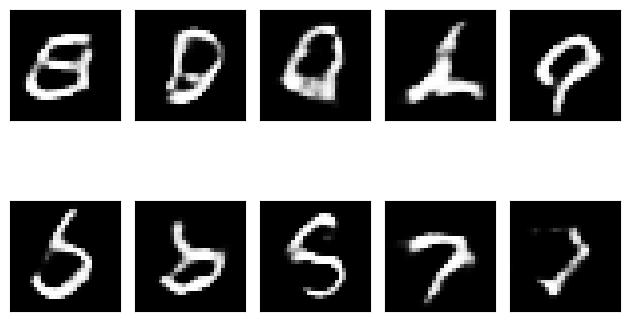

Epoch: 19, disc. loss: 0.6829506754875183, gen. loss: 0.7486607432365417. Time for epoch 20 is 28.218486547470093 sec
Epoch: 20, disc. loss: 0.6266913414001465, gen. loss: 0.8060452342033386. Time for epoch 21 is 27.788296699523926 sec
Epoch: 21, disc. loss: 0.5766416788101196, gen. loss: 0.8909929990768433. Time for epoch 22 is 27.951851844787598 sec
Epoch: 22, disc. loss: 0.6982861161231995, gen. loss: 0.6455603837966919. Time for epoch 23 is 27.81561255455017 sec
Epoch: 23, disc. loss: 0.6454740762710571, gen. loss: 0.8468627333641052. Time for epoch 24 is 27.71018958091736 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


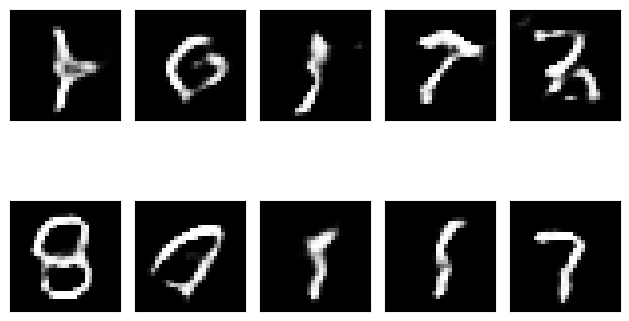

Epoch: 24, disc. loss: 0.6606882810592651, gen. loss: 0.9010989665985107. Time for epoch 25 is 28.045571327209473 sec
Epoch: 25, disc. loss: 0.6815518140792847, gen. loss: 0.6588132381439209. Time for epoch 26 is 27.952836990356445 sec
Epoch: 26, disc. loss: 0.6327749490737915, gen. loss: 0.7939207553863525. Time for epoch 27 is 27.738751888275146 sec
Epoch: 27, disc. loss: 0.6388651132583618, gen. loss: 0.7785995602607727. Time for epoch 28 is 27.791669845581055 sec
Epoch: 28, disc. loss: 0.6905533075332642, gen. loss: 0.879011332988739. Time for epoch 29 is 27.745048999786377 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


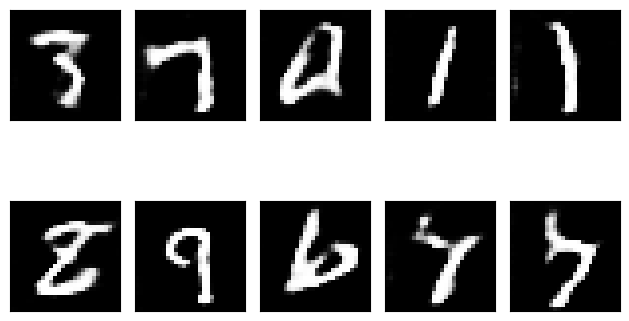

Epoch: 29, disc. loss: 0.6914482712745667, gen. loss: 0.6917665004730225. Time for epoch 30 is 28.129663944244385 sec
Epoch: 30, disc. loss: 0.6446421146392822, gen. loss: 0.7088440656661987. Time for epoch 31 is 27.67567229270935 sec
Epoch: 31, disc. loss: 0.6326317191123962, gen. loss: 0.7803282737731934. Time for epoch 32 is 27.726627588272095 sec
Epoch: 32, disc. loss: 0.6277492046356201, gen. loss: 0.6967533826828003. Time for epoch 33 is 27.645063161849976 sec
Epoch: 33, disc. loss: 0.6522276401519775, gen. loss: 0.7248563766479492. Time for epoch 34 is 27.674770832061768 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


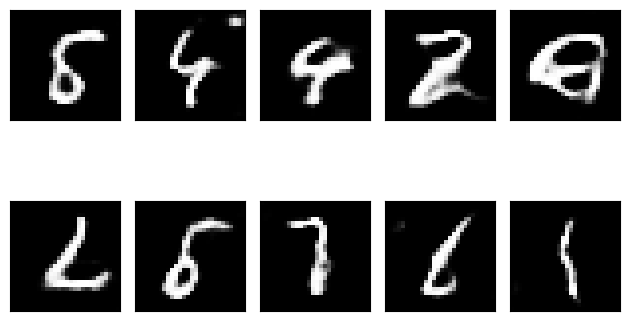

Epoch: 34, disc. loss: 0.6472052335739136, gen. loss: 0.8237048983573914. Time for epoch 35 is 28.163541793823242 sec
Epoch: 35, disc. loss: 0.6594966053962708, gen. loss: 0.7330038547515869. Time for epoch 36 is 27.810986518859863 sec
Epoch: 36, disc. loss: 0.7237454652786255, gen. loss: 0.8144419193267822. Time for epoch 37 is 28.054361581802368 sec
Epoch: 37, disc. loss: 0.6176223158836365, gen. loss: 0.7373002767562866. Time for epoch 38 is 27.73546051979065 sec
Epoch: 38, disc. loss: 0.6050081849098206, gen. loss: 0.7124719619750977. Time for epoch 39 is 27.68042278289795 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


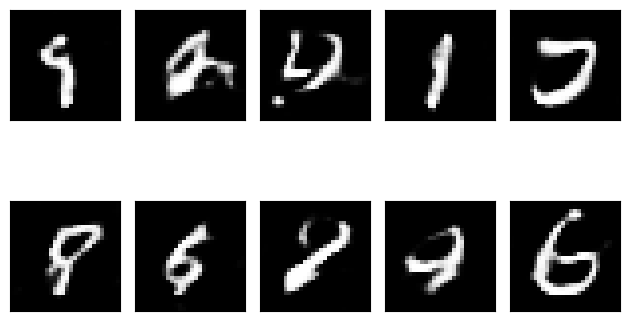

Epoch: 39, disc. loss: 0.6624480485916138, gen. loss: 0.8115559816360474. Time for epoch 40 is 28.128145217895508 sec
Epoch: 40, disc. loss: 0.6388579607009888, gen. loss: 0.7187438011169434. Time for epoch 41 is 27.70089864730835 sec
Epoch: 41, disc. loss: 0.6441799402236938, gen. loss: 0.8661528825759888. Time for epoch 42 is 27.75705909729004 sec
Epoch: 42, disc. loss: 0.6414023041725159, gen. loss: 0.8605808615684509. Time for epoch 43 is 27.808765649795532 sec
Epoch: 43, disc. loss: 0.6384750604629517, gen. loss: 0.8321516513824463. Time for epoch 44 is 27.72591519355774 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


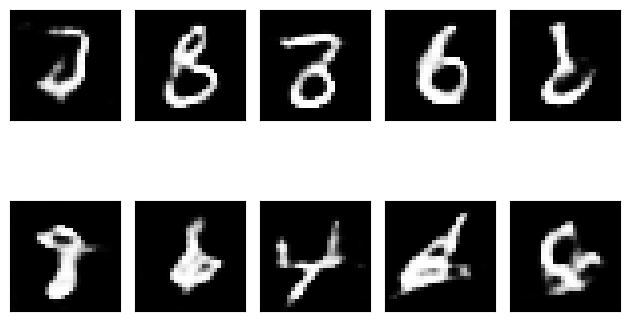

Epoch: 44, disc. loss: 0.6119362115859985, gen. loss: 0.7773504257202148. Time for epoch 45 is 28.085973262786865 sec
Epoch: 45, disc. loss: 0.6714037656784058, gen. loss: 0.7037317156791687. Time for epoch 46 is 27.74101209640503 sec
Epoch: 46, disc. loss: 0.6702830791473389, gen. loss: 0.817865788936615. Time for epoch 47 is 27.730327367782593 sec
Epoch: 47, disc. loss: 0.6613247990608215, gen. loss: 0.8163595795631409. Time for epoch 48 is 27.73519277572632 sec
Epoch: 48, disc. loss: 0.7033236026763916, gen. loss: 0.947550892829895. Time for epoch 49 is 27.864508628845215 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


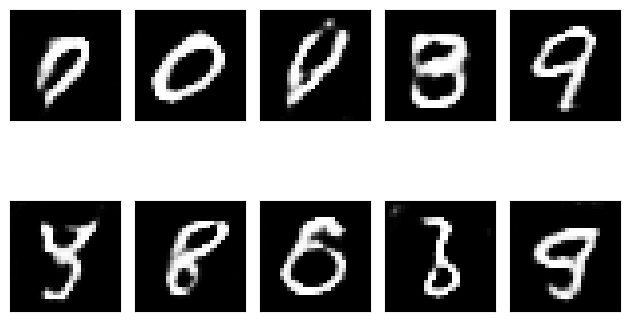

Epoch: 49, disc. loss: 0.6682091951370239, gen. loss: 0.9005500674247742. Time for epoch 50 is 27.950289964675903 sec
Epoch: 50, disc. loss: 0.6675442457199097, gen. loss: 0.7612061500549316. Time for epoch 51 is 27.711400985717773 sec
Epoch: 51, disc. loss: 0.6415316462516785, gen. loss: 0.7710812091827393. Time for epoch 52 is 27.72851324081421 sec
Epoch: 52, disc. loss: 0.6524689197540283, gen. loss: 0.778603196144104. Time for epoch 53 is 27.6522536277771 sec
Epoch: 53, disc. loss: 0.73133385181427, gen. loss: 0.9588013887405396. Time for epoch 54 is 27.70665955543518 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step


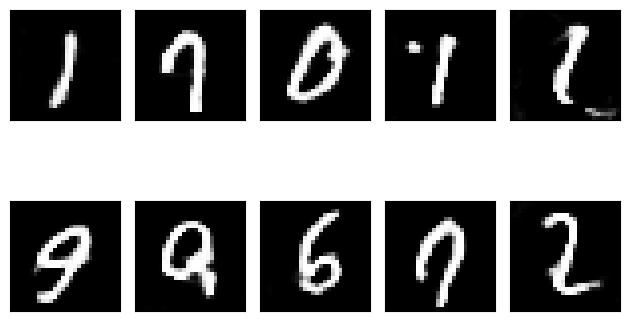

Epoch: 54, disc. loss: 0.6496894359588623, gen. loss: 0.7716796398162842. Time for epoch 55 is 28.066566467285156 sec
Epoch: 55, disc. loss: 0.6641092300415039, gen. loss: 0.7421061992645264. Time for epoch 56 is 27.732043743133545 sec
Epoch: 56, disc. loss: 0.6617740392684937, gen. loss: 0.8206241130828857. Time for epoch 57 is 27.67121148109436 sec
Epoch: 57, disc. loss: 0.6686054468154907, gen. loss: 0.749169111251831. Time for epoch 58 is 27.648210763931274 sec
Epoch: 58, disc. loss: 0.6437387466430664, gen. loss: 0.6741781234741211. Time for epoch 59 is 27.60038137435913 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


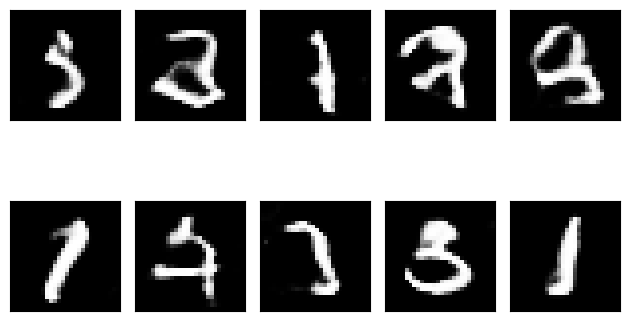

Epoch: 59, disc. loss: 0.6695641279220581, gen. loss: 0.7232227921485901. Time for epoch 60 is 28.437665700912476 sec
Epoch: 60, disc. loss: 0.6998829245567322, gen. loss: 0.6002140045166016. Time for epoch 61 is 27.92026710510254 sec
Epoch: 61, disc. loss: 0.6840907335281372, gen. loss: 0.7539662718772888. Time for epoch 62 is 27.805696725845337 sec
Epoch: 62, disc. loss: 0.6933567523956299, gen. loss: 1.0902273654937744. Time for epoch 63 is 27.85192632675171 sec
Epoch: 63, disc. loss: 0.6497042179107666, gen. loss: 0.853334903717041. Time for epoch 64 is 27.81786346435547 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


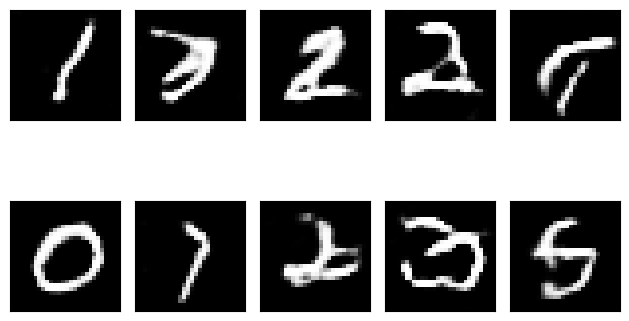

Epoch: 64, disc. loss: 0.6675541400909424, gen. loss: 0.6846996545791626. Time for epoch 65 is 28.224977016448975 sec
Epoch: 65, disc. loss: 0.6403659582138062, gen. loss: 0.8327157497406006. Time for epoch 66 is 27.840294122695923 sec
Epoch: 66, disc. loss: 0.6651372313499451, gen. loss: 0.7805622816085815. Time for epoch 67 is 27.80159640312195 sec
Epoch: 67, disc. loss: 0.6727300882339478, gen. loss: 0.7272037863731384. Time for epoch 68 is 27.75955557823181 sec
Epoch: 68, disc. loss: 0.7477030754089355, gen. loss: 0.907912015914917. Time for epoch 69 is 27.78589653968811 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


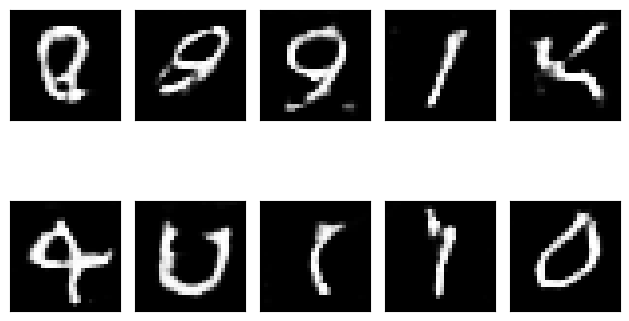

Epoch: 69, disc. loss: 0.6857224702835083, gen. loss: 0.9311626553535461. Time for epoch 70 is 28.16925835609436 sec
Epoch: 70, disc. loss: 0.6063729524612427, gen. loss: 0.807156503200531. Time for epoch 71 is 27.965874910354614 sec
Epoch: 71, disc. loss: 0.6633752584457397, gen. loss: 0.6835744976997375. Time for epoch 72 is 27.737020254135132 sec
Epoch: 72, disc. loss: 0.6685386300086975, gen. loss: 0.7435206174850464. Time for epoch 73 is 27.871198177337646 sec
Epoch: 73, disc. loss: 0.6465140581130981, gen. loss: 0.6744893789291382. Time for epoch 74 is 27.79867124557495 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


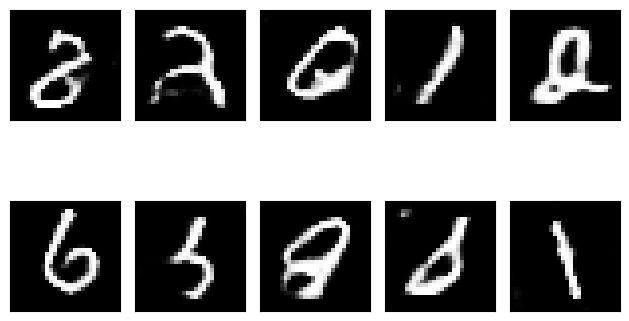

Epoch: 74, disc. loss: 0.656204879283905, gen. loss: 0.6763404011726379. Time for epoch 75 is 28.164019346237183 sec
Epoch: 75, disc. loss: 0.6398755311965942, gen. loss: 0.7559419870376587. Time for epoch 76 is 27.832313537597656 sec
Epoch: 76, disc. loss: 0.5932055115699768, gen. loss: 0.793845534324646. Time for epoch 77 is 27.640530586242676 sec
Epoch: 77, disc. loss: 0.6462845206260681, gen. loss: 0.7736466526985168. Time for epoch 78 is 27.854095935821533 sec
Epoch: 78, disc. loss: 0.6446818709373474, gen. loss: 0.715817928314209. Time for epoch 79 is 27.740426778793335 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


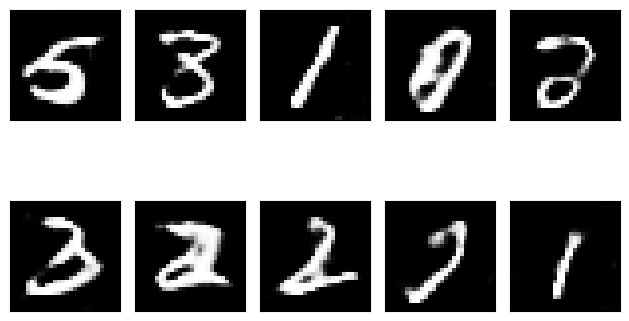

Epoch: 79, disc. loss: 0.6490112543106079, gen. loss: 0.7831157445907593. Time for epoch 80 is 28.19931435585022 sec
Epoch: 80, disc. loss: 0.6481961011886597, gen. loss: 0.8295050263404846. Time for epoch 81 is 27.703087329864502 sec
Epoch: 81, disc. loss: 0.6746604442596436, gen. loss: 0.8988311290740967. Time for epoch 82 is 27.86284041404724 sec
Epoch: 82, disc. loss: 0.6989017724990845, gen. loss: 0.829128623008728. Time for epoch 83 is 27.73689889907837 sec
Epoch: 83, disc. loss: 0.6629174947738647, gen. loss: 0.6987743377685547. Time for epoch 84 is 27.68804931640625 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step


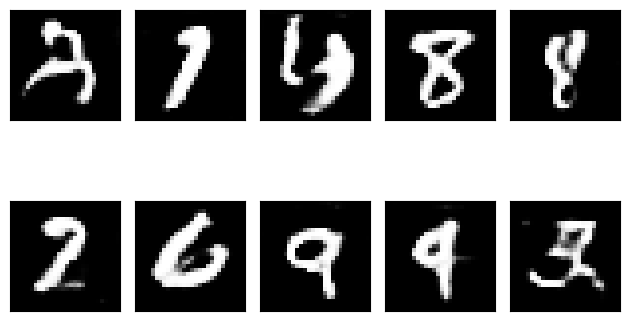

Epoch: 84, disc. loss: 0.6144599914550781, gen. loss: 0.7721070647239685. Time for epoch 85 is 28.020856857299805 sec
Epoch: 85, disc. loss: 0.6395212411880493, gen. loss: 0.7931864857673645. Time for epoch 86 is 27.73071575164795 sec
Epoch: 86, disc. loss: 0.6710407733917236, gen. loss: 0.7588571906089783. Time for epoch 87 is 27.777918100357056 sec
Epoch: 87, disc. loss: 0.6693569421768188, gen. loss: 0.7199230790138245. Time for epoch 88 is 27.799366235733032 sec
Epoch: 88, disc. loss: 0.6931033730506897, gen. loss: 0.6423839330673218. Time for epoch 89 is 27.732327699661255 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step


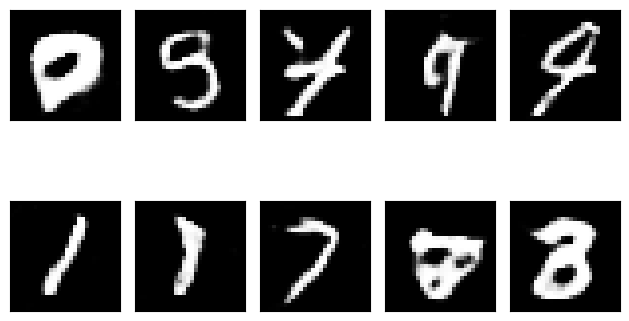

Epoch: 89, disc. loss: 0.6522413492202759, gen. loss: 0.7965767979621887. Time for epoch 90 is 28.055920124053955 sec
Epoch: 90, disc. loss: 0.6642585396766663, gen. loss: 0.7291760444641113. Time for epoch 91 is 27.78925919532776 sec
Epoch: 91, disc. loss: 0.6205490827560425, gen. loss: 0.7490198612213135. Time for epoch 92 is 27.67619490623474 sec
Epoch: 92, disc. loss: 0.730417013168335, gen. loss: 0.7306867837905884. Time for epoch 93 is 27.91777467727661 sec
Epoch: 93, disc. loss: 0.5917909145355225, gen. loss: 0.807341456413269. Time for epoch 94 is 27.63452672958374 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


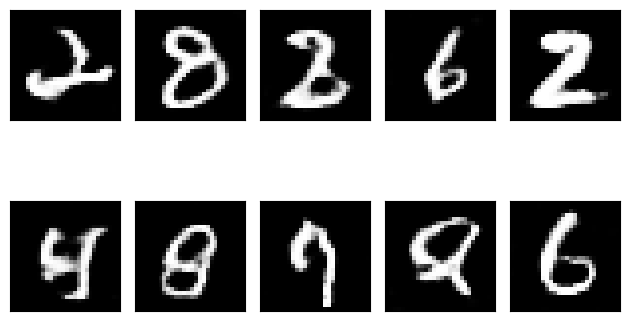

Epoch: 94, disc. loss: 0.678012490272522, gen. loss: 0.6803085207939148. Time for epoch 95 is 28.034725427627563 sec
Epoch: 95, disc. loss: 0.6749594211578369, gen. loss: 0.7480618953704834. Time for epoch 96 is 27.65506386756897 sec
Epoch: 96, disc. loss: 0.640224039554596, gen. loss: 0.7626664042472839. Time for epoch 97 is 27.67520523071289 sec
Epoch: 97, disc. loss: 0.6657205820083618, gen. loss: 0.799299955368042. Time for epoch 98 is 27.675492763519287 sec
Epoch: 98, disc. loss: 0.6987718343734741, gen. loss: 0.9152042269706726. Time for epoch 99 is 27.7665536403656 sec
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


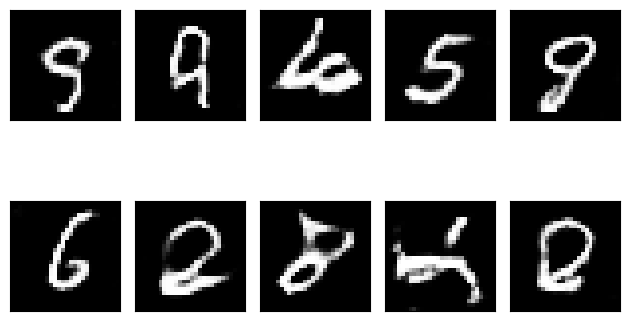

Epoch: 99, disc. loss: 0.6735613346099854, gen. loss: 0.8360169529914856. Time for epoch 100 is 28.012749910354614 sec


In [8]:
import time

# smooth = 0.1
add_noise_labels = True
noise_labels = 0.02

gen_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
disc_optimizer = Adam( learning_rate=0.0002, beta_1=0.5 )
cross_entropy = tf.keras.losses.BinaryCrossentropy(from_logits=True)

@tf.function
def train_step( X_real ):
    z = tf.random.normal( [batch_size, latent_dim] )

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
      X_fake = generator( z, training=True )

      real_output = discriminator( X_real, training=True)
      fake_output = discriminator( X_fake, training=True)

      y_real = tf.ones_like(real_output)
      y_fake = tf.zeros_like(fake_output)
      # Add random noise to the labels
      if add_noise_labels:
          y_real += noise_labels * tf.random.uniform(tf.shape(y_real))
          y_fake += noise_labels * tf.random.uniform(tf.shape(y_fake))
        
      real_loss = cross_entropy( y_real, real_output)
      fake_loss = cross_entropy( y_fake, fake_output)
      disc_loss = 0.5 * ( real_loss + fake_loss )
        
      gen_loss = cross_entropy( tf.ones_like(fake_output), fake_output )

    gen_grads  = gen_tape.gradient( gen_loss, generator.trainable_variables )
    disc_grads = disc_tape.gradient( disc_loss, discriminator.trainable_variables )

    gen_optimizer.apply_gradients( zip( gen_grads, generator.trainable_variables) )
    disc_optimizer.apply_gradients( zip( disc_grads, discriminator.trainable_variables) )

    return (disc_loss, gen_loss)

def train(dataset, epochs):
  for epoch in range(epochs):
    start = time.time()

    for X_batch in dataset:
      dloss, gloss = train_step( X_batch )

    if (epoch + 1) % 5 == 0:
        samples = 10
        X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
        for k in range(samples):
            plt.subplot(2, 5, k+1)
            plt.imshow( X_[k].reshape(28, 28), cmap='gray')
            plt.xticks([])
            plt.yticks([])
        plt.tight_layout()
        plt.show()

    print ( "Epoch: {}, disc. loss: {}, gen. loss: {}.".format( epoch, dloss, gloss ),
            "Time for epoch {} is {} sec".format(epoch + 1, time.time()-start) )
   
epochs = 100
train(train_dataset, epochs)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step


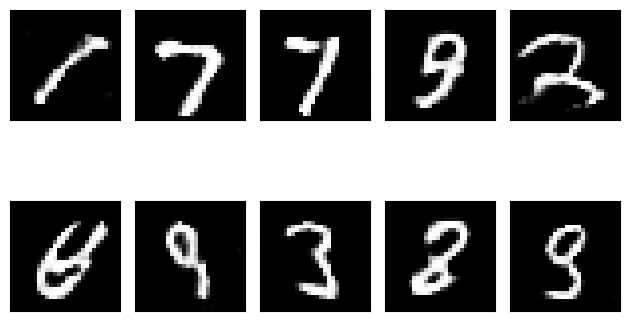

In [9]:
samples = 10
X_ = generator.predict( tf.random.normal( [samples, latent_dim] ) )
for k in range(samples):
    plt.subplot(2, 5, k+1)
    plt.imshow( X_[k].reshape(28, 28), cmap='gray')
    plt.xticks([])
    plt.yticks([])
plt.tight_layout()
plt.show()